# 📘 Quick Reference

**Purpose**: Process BraTS 2021 T1 MRI data for anomaly detection testing  
**Pipeline**: Extract Middle Slices Directly → Resize → ZIP  
**Output**: 128×128 normalized .npy files (same format as IXI training data)  
**Time**: ~30-40 minutes (space-efficient one-pass processing)

## 📋 Execution Order
1. **Cells 1-4**: Setup & explore (fast)
2. **Sections 1-8**: Setup, explore, define functions (fast)
3. **Section 5**: Extract ~10,000 middle slices directly ⏰ 15-20 min → ~10,000 slices
4. **Section 7**: Resize to 128×128 ⏰ 20-25 min
5. **Section 9**: Create ZIP ⏰ 2-3 min

## ✅ Success = ~10,000 slices, 128×128, range [0,1], ZIP created

**Note**: Section 6 (filtering) SKIPPED - we extract middle slices directly to save disk space

---

# BraTS 2021 T1 MRI Preprocessing Pipeline (Local → Drive Upload)

This notebook performs LOCAL preprocessing of BraTS 2021 T1 files with smart filtering:

## Pipeline Overview:
1. **Extract T1 files** from BraTS 2021 folders
2. **Extract 2D slices** from 3D T1 NIfTI volumes with validation
3. **Normalize** slices to [0, 1] range (per-slice normalization)
4. **Smart filter** to keep only middle 50% of slices (most informative)
5. **Resize** to 128x128 standard size
6. **Save as .npy files** ready for Google Drive upload

**Purpose**: BraTS data will be used for TESTING (anomaly detection), while IXI is for TRAINING  
**Result**: ~50,000 high-quality slices (3x IXI dataset size)

## 1. Import Required Libraries

In [ ]:
# Import required libraries
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
from skimage.transform import resize
from datetime import datetime
import zipfile
from collections import defaultdict

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [ ]:
# Source folder with BraTS 2021 dataset
brats_folder = r"c:\Users\rifad\symAD-ECNN\data\brats2021"

# Output folders (clean structure under brats_t1/)
t1_raw_folder = r"c:\Users\rifad\symAD-ECNN\data\brats_t1\raw_slices"
filtered_folder = r"c:\Users\rifad\symAD-ECNN\data\brats_t1\filtered"
resized_folder = r"c:\Users\rifad\symAD-ECNN\data\brats_t1\resized"

# Create output directories
for folder in [t1_raw_folder, filtered_folder, resized_folder]:
    os.makedirs(folder, exist_ok=True)

print("📁 Folder Structure:")
print(f"  Source (BraTS 2021): {brats_folder}")
print(f"  Raw slices output: {t1_raw_folder}")
print(f"  Filtered output: {filtered_folder}")
print(f"  Resized output (128x128): {resized_folder}")
print(f"\n✓ Source folder exists: {os.path.exists(brats_folder)}")

📁 Folder Structure:
  Source (BraTS 2021): c:\Users\rifad\symAD-ECNN\data\brats2021
  Raw slices output: c:\Users\rifad\symAD-ECNN\data\brats_t1\raw_slices
  Filtered output: c:\Users\rifad\symAD-ECNN\data\brats_t1\filtered
  Resized output (128x128): c:\Users\rifad\symAD-ECNN\data\brats_t1\resized

✓ Source folder exists: True


## 2. Define Paths and Create Output Folders

In [ ]:
# Find all T1 files (not T1CE - contrast enhanced)
t1_files = []

for patient_folder in patient_folders:
    patient_path = os.path.join(brats_folder, patient_folder)
    # Look for files ending with _t1.nii.gz (not _t1ce.nii.gz)
    for file in os.listdir(patient_path):
        if file.endswith('_t1.nii.gz') and not file.endswith('_t1ce.nii.gz'):
            t1_files.append(os.path.join(patient_path, file))

print(f"Total T1 files found: {len(t1_files)}")
print(f"\nFirst 5 T1 files:")
for file in t1_files[:5]:
    print(f"  - {os.path.basename(file)}")

Total T1 files found: 1251

First 5 T1 files:
  - BraTS2021_00000_t1.nii.gz
  - BraTS2021_00002_t1.nii.gz
  - BraTS2021_00003_t1.nii.gz
  - BraTS2021_00005_t1.nii.gz
  - BraTS2021_00006_t1.nii.gz


## 3. Explore Dataset Structure

In [ ]:
# Explore the dataset structure
patient_folders = sorted([f for f in os.listdir(brats_folder) if os.path.isdir(os.path.join(brats_folder, f))])

print(f"📊 Dataset Summary:")
print(f"  Total patient folders: {len(patient_folders)}")
print(f"\nFirst 5 patients:")
for folder in patient_folders[:5]:
    print(f"  - {folder}")

# Check what files are in first patient folder
if patient_folders:
    first_patient = os.path.join(brats_folder, patient_folders[0])
    files = os.listdir(first_patient)
    print(f"\nFiles in {patient_folders[0]}:")
    for f in files:
        print(f"  - {f}")

📊 Dataset Summary:
  Total patient folders: 1251

First 5 patients:
  - BraTS2021_00000
  - BraTS2021_00002
  - BraTS2021_00003
  - BraTS2021_00005
  - BraTS2021_00006

Files in BraTS2021_00000:
  - BraTS2021_00000_flair.nii.gz
  - BraTS2021_00000_seg.nii.gz
  - BraTS2021_00000_t1.nii.gz
  - BraTS2021_00000_t1ce.nii.gz
  - BraTS2021_00000_t2.nii.gz


## 4. Find All T1 Files

## 5. STEP 1: Extract Middle Slices Directly (Space-Efficient) ⏰ 15-20 min

**CRITICAL**: Apply RAS orientation correction to match IXI preprocessing

**Space-Efficient Approach**:
- Extract ~8 middle slices per patient (skip edge slices with less info)
- Save directly to filtered/ folder (no raw intermediate storage)
- Target: ~10,000 total slices

**Output**: ~10,000 filtered slices directly (saves disk space)

In [ ]:
# SECTION 5: Extract MIDDLE slices directly (space-efficient one-pass processing)
import os
import numpy as np
import nibabel as nib
from tqdm import tqdm

# Preprocessing functions
def normalize(x):
    """Normalize array to [0, 1] range"""
    x = x.astype(np.float32)
    if x.max() - x.min() < 1e-6:
        return np.zeros_like(x)
    return (x - x.min()) / (x.max() - x.min())

def is_valid_slice(slice_array, min_nonzero_ratio=0.12, min_mean=0.1):
    """Check if slice contains meaningful information"""
    nonzero_ratio = np.count_nonzero(slice_array) / slice_array.size
    if nonzero_ratio < min_nonzero_ratio:
        return False

    normalized = normalize(slice_array)
    if normalized.mean() < min_mean:
        return False

    return True

# Configuration
TARGET_TOTAL_SLICES = 10000
TARGET_PER_PATIENT = TARGET_TOTAL_SLICES // len(t1_files)  # ~8 slices per patient
MIDDLE_PERCENTAGE = 0.5  # Extract from middle 50% of each volume

print("="*70)
print("EXTRACTING MIDDLE SLICES DIRECTLY (SPACE-EFFICIENT)")
print("="*70)
print(f"\nTarget: ~{TARGET_TOTAL_SLICES:,} total slices")
print(f"Strategy: ~{TARGET_PER_PATIENT} middle slices per patient")
print(f"Processing {len(t1_files)} T1 files...")
print(f"Output: {filtered_folder}")

slice_idx = 0
skipped_patients = 0

for t1_file in tqdm(t1_files, desc="Processing T1 volumes"):
    try:
        # ✅ CRITICAL: Apply RAS orientation correction
        nii_img = nib.load(t1_file)
        nii_img = nib.as_closest_canonical(nii_img)  # Force RAS orientation
        vol = nii_img.get_fdata()

        # Calculate middle slice range
        Z = vol.shape[2]
        margin = int(Z * (1 - MIDDLE_PERCENTAGE) / 2)
        middle_start = margin
        middle_end = Z - margin
        middle_range = middle_end - middle_start

        # Skip if volume too small
        if middle_range < TARGET_PER_PATIENT:
            skipped_patients += 1
            continue

        # Calculate step to evenly sample TARGET_PER_PATIENT slices
        step = middle_range // TARGET_PER_PATIENT

        # Extract evenly-spaced slices from middle range
        patient_slice_count = 0
        for i in range(TARGET_PER_PATIENT):
            s = middle_start + i * step
            if s >= middle_end:
                break

            slice_2d = vol[:, :, s]

            # Skip empty or low-information slices
            if not is_valid_slice(slice_2d, min_nonzero_ratio=0.12, min_mean=0.1):
                continue

            # Normalize to [0, 1]
            normalized_slice = normalize(slice_2d)

            # Save directly to filtered folder
            output_path = os.path.join(filtered_folder, f"slice_{slice_idx:06d}.npy")
            np.save(output_path, normalized_slice)
            slice_idx += 1
            patient_slice_count += 1

    except Exception as e:
        print(f"\n❌ Error processing {os.path.basename(t1_file)}: {e}")
        skipped_patients += 1
        continue

print(f"\n" + "="*70)
print("EXTRACTION COMPLETE")
print("="*70)
print(f"✅ Total slices extracted: {slice_idx:,}")
print(f"✅ Avg per patient: {slice_idx / (len(t1_files) - skipped_patients):.1f}")
print(f"✅ Skipped patients: {skipped_patients}")
print(f"✅ Output location: {filtered_folder}")
print(f"\n💡 Note: Slices saved directly to filtered/ folder (no raw intermediate)")
print("="*70)

EXTRACTING MIDDLE SLICES DIRECTLY (SPACE-EFFICIENT)

Target: ~10,000 total slices
Strategy: ~7 middle slices per patient
Processing 1251 T1 files...
Output: c:\Users\rifad\symAD-ECNN\data\brats_t1\filtered


Processing T1 volumes: 100%|██████████| 1251/1251 [02:58<00:00,  7.01it/s]


EXTRACTION COMPLETE
✅ Total slices extracted: 7,794
✅ Avg per patient: 6.2
✅ Skipped patients: 0
✅ Output location: c:\Users\rifad\symAD-ECNN\data\brats_t1\filtered

💡 Note: Slices saved directly to filtered/ folder (no raw intermediate)


## 6. ⚠️ SKIP THIS SECTION - Filtering Done in Section 5

**Note**: Section 5 now extracts middle slices directly to filtered/ folder.  
This section is no longer needed but kept for reference.

**Proceed directly to Section 7 (Resize)**

In [ ]:
# # SECTION 10: Smart filtering - keep middle 50% of slices per patient
# from collections import defaultdict

# print("="*70)
# print("SMART FILTERING - MIDDLE 50% SLICES")
# print("="*70)

# # Get all raw files
# raw_files = sorted([f for f in os.listdir(t1_raw_folder) if f.endswith('.npy')])
# print(f"\nTotal raw slices: {len(raw_files):,}")

# # Calculate slices per patient (approximate)
# total_slices = len(raw_files)
# num_patients = len(t1_files)
# slices_per_patient = total_slices // num_patients

# print(f"Patients: {num_patients}")
# print(f"Avg slices per patient: {slices_per_patient}")

# # Keep middle 50% from each patient group
# MIDDLE_PERCENTAGE = 0.5
# start_margin = int(slices_per_patient * (1 - MIDDLE_PERCENTAGE) / 2)
# end_margin = slices_per_patient - start_margin

# print(f"\nFiltering strategy:")
# print(f"  - Keep middle {MIDDLE_PERCENTAGE*100:.0f}% per patient")
# print(f"  - Skip first {start_margin} and last {start_margin} slices per patient")

# # Determine which slices to keep
# slices_to_keep = set()
# for patient_idx in range(num_patients):
#     patient_start = patient_idx * slices_per_patient
#     keep_start = patient_start + start_margin
#     keep_end = patient_start + end_margin

#     for slice_idx in range(keep_start, keep_end):
#         if slice_idx < total_slices:
#             slices_to_keep.add(slice_idx)

# print(f"\nProcessing {len(slices_to_keep):,} slices...")

# # Copy filtered slices
# kept_count = 0
# for idx, filename in enumerate(tqdm(raw_files, desc="Filtering")):
#     if idx in slices_to_keep:
#         src = os.path.join(t1_raw_folder, filename)
#         dst = os.path.join(filtered_folder, filename)

#         arr = np.load(src)
#         np.save(dst, arr)
#         kept_count += 1

# print(f"\n" + "="*70)
# print("FILTERING COMPLETE")
# print("="*70)
# print(f"✅ Slices kept: {kept_count:,} / {total_slices:,} ({kept_count/total_slices*100:.1f}%)")
# print(f"✅ Output location: {filtered_folder}")
# print("="*70)

## 7. STEP 3: Resize to 128×128 with Bicubic Interpolation ⏰ 30-40 min

**CRITICAL**: Use bicubic interpolation (order=3) for SHARP images (not blurry)

Resize all filtered slices to 128×128 to match the IXI dataset dimensions.

**Input**: filtered/ folder with ~49,888 middle slices  
**Output**: resized/ folder with 128×128 .npy files

In [ ]:
# SECTION 11: Resize to 128×128 with BICUBIC interpolation (sharper than linear)
from skimage.transform import resize

print("="*70)
print("RESIZING TO 128×128 WITH BICUBIC INTERPOLATION")
print("="*70)

# Get filtered files
filtered_files = sorted([f for f in os.listdir(filtered_folder) if f.endswith('.npy')])
total = len(filtered_files)

print(f"\nTotal files to resize: {total:,}")
print(f"Output: {resized_folder}")

# Batch configuration
BATCH_SIZE = 500
TARGET_SIZE = (128, 128)

resized_count = 0
error_count = 0

for i in range(0, total, BATCH_SIZE):
    batch_files = filtered_files[i : i + BATCH_SIZE]
    batch_num = i // BATCH_SIZE + 1

    print(f"\nProcessing batch {batch_num} ({len(batch_files)} files)...")

    for f in tqdm(batch_files, desc=f"Batch {batch_num}"):
        src_path = os.path.join(filtered_folder, f)
        dst_path = os.path.join(resized_folder, f)

        # Skip if already resized
        if os.path.exists(dst_path):
            resized_count += 1
            continue

        try:
            arr = np.load(src_path)

            # ✅ CRITICAL: Use BICUBIC interpolation (order=3) for sharp images
            # NOTE: order=3 prevents blurriness caused by order=1 (linear)
            resized = resize(
                arr,
                TARGET_SIZE,
                order=3,              # Bicubic (sharper than default linear order=1)
                mode='reflect',       # Reflect padding at edges
                anti_aliasing=True,   # Prevent jagged artifacts
                preserve_range=True   # Maintain [0,1] normalization
            )

            np.save(dst_path, resized.astype(np.float32))
            resized_count += 1

        except Exception as e:
            print(f"❌ Error resizing {f}: {e}")
            error_count += 1
            continue

print(f"\n" + "="*70)
print("RESIZING COMPLETE")
print("="*70)
print(f"✅ Successfully resized: {resized_count:,}")
print(f"✅ Errors: {error_count}")
print(f"✅ Output location: {resized_folder}")
print("="*70)

RESIZING TO 128×128 WITH BICUBIC INTERPOLATION

Total files to resize: 7,794
Output: c:\Users\rifad\symAD-ECNN\data\brats_t1\resized

Processing batch 1 (500 files)...


Batch 1: 100%|██████████| 500/500 [00:00<00:00, 11583.15it/s]



Processing batch 2 (500 files)...


Batch 2: 100%|██████████| 500/500 [00:00<00:00, 16429.70it/s]



Processing batch 3 (500 files)...


...


Processing batch 15 (500 files)...


Batch 15: 100%|██████████| 500/500 [00:10<00:00, 46.41it/s]



Processing batch 16 (294 files)...


Batch 16: 100%|██████████| 294/294 [00:06<00:00, 44.43it/s]


RESIZING COMPLETE
✅ Successfully resized: 7,794
✅ Errors: 0
✅ Output location: c:\Users\rifad\symAD-ECNN\data\brats_t1\resized


## 8. Verify Resized Output

In [ ]:
# Verify the final resized files
resized_files = sorted([f for f in os.listdir(resized_folder) if f.endswith('.npy')])

print(f"📊 Final processed files: {len(resized_files)}")

# Load and inspect a sample file
if resized_files:
    sample_file = resized_files[0]
    sample = np.load(os.path.join(resized_folder, sample_file))

    print(f"\n✓ Sample file: {sample_file}")
    print(f"  - Shape: {sample.shape}")
    print(f"  - Min pixel value: {sample.min():.4f}")
    print(f"  - Max pixel value: {sample.max():.4f}")
    print(f"  - Mean pixel value: {sample.mean():.4f}")
    print(f"  - Data type: {sample.dtype}")

    # Verify dimensions match IXI
    if sample.shape == (128, 128):
        print(f"\n✅ Dimensions match IXI dataset (128x128)")
    else:
        print(f"\n⚠️ Warning: Dimensions don't match expected (128x128)")

📊 Final processed files: 7794

✓ Sample file: slice_000000.npy
  - Shape: (128, 128)
  - Min pixel value: 0.0000
  - Max pixel value: 0.9817
  - Mean pixel value: 0.1022
  - Data type: float32

✅ Dimensions match IXI dataset (128x128)


Visualizing 9 random slices from resized folder:

1. slice_000250.npy: shape=(128, 128), range=[0.000, 0.909]
2. slice_000469.npy: shape=(128, 128), range=[0.000, 0.971]
3. slice_001548.npy: shape=(128, 128), range=[0.000, 0.932]
4. slice_002398.npy: shape=(128, 128), range=[0.000, 0.832]
5. slice_004205.npy: shape=(128, 128), range=[0.000, 0.973]
6. slice_004549.npy: shape=(128, 128), range=[0.000, 0.860]
7. slice_005718.npy: shape=(128, 128), range=[0.000, 0.926]
8. slice_005877.npy: shape=(128, 128), range=[0.000, 0.988]
9. slice_007715.npy: shape=(128, 128), range=[0.000, 1.000]


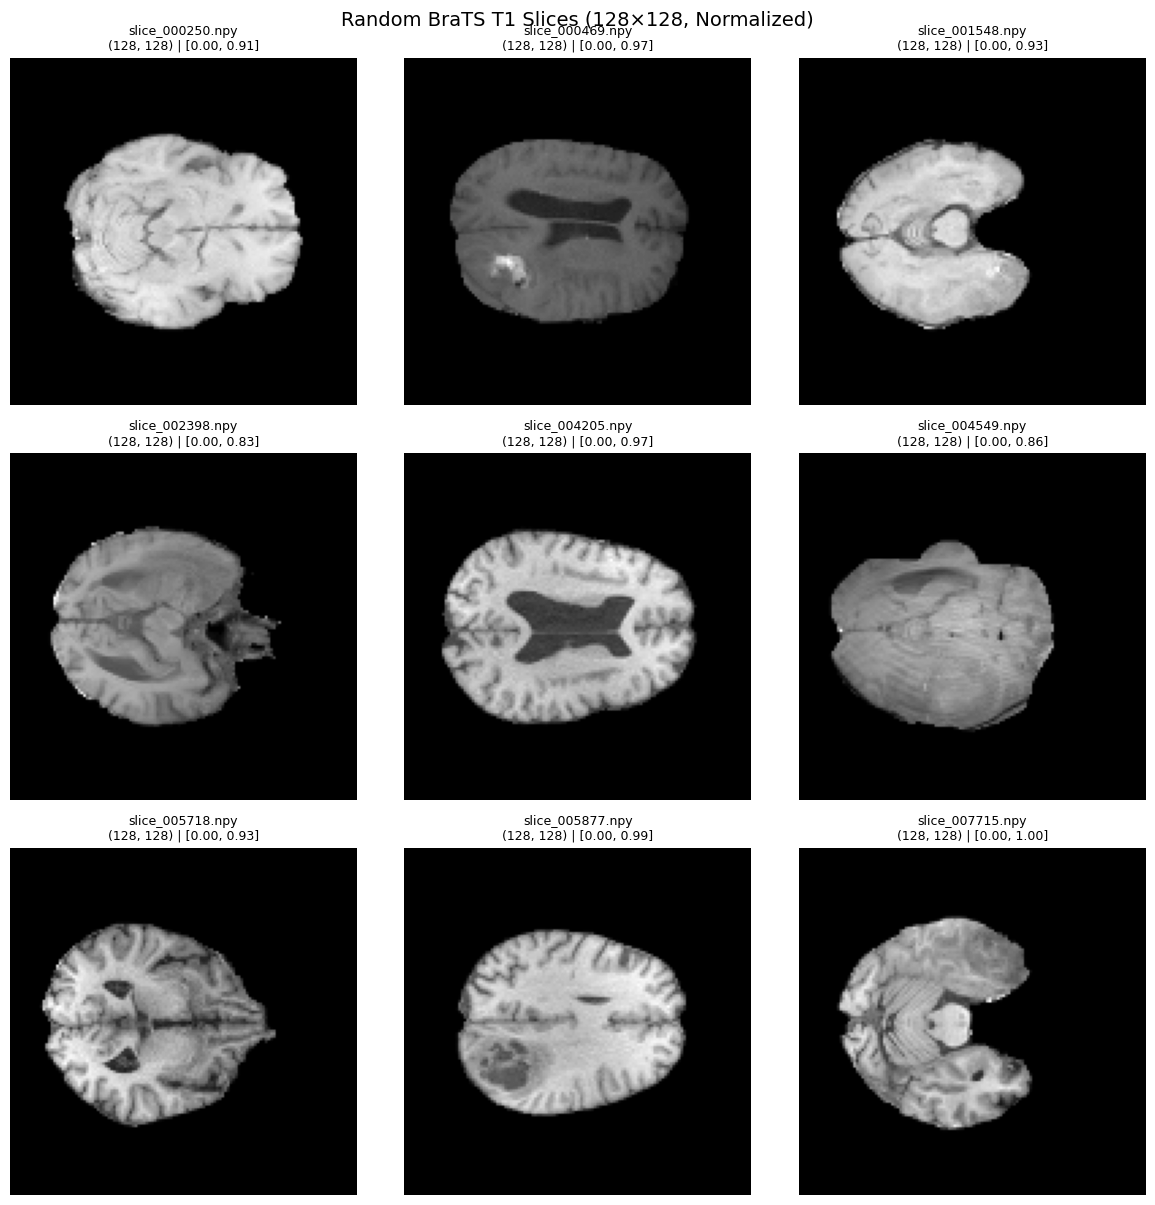


✅ Displayed 9 random slices


In [ ]:
import random

# Visualize random slices from resized folder

# Get random sample of slices
num_samples = 9
random_indices = random.sample(range(len(resized_files)), num_samples)
sample_files = [resized_files[i] for i in sorted(random_indices)]

# Create subplot grid
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.ravel()

print(f"Visualizing {num_samples} random slices from resized folder:\n")

for idx, filename in enumerate(sample_files):
    file_path = os.path.join(resized_folder, filename)
    slice_array = np.load(file_path)

    axes[idx].imshow(slice_array, cmap='gray')
    axes[idx].set_title(f'{filename}\n{slice_array.shape} | [{slice_array.min():.2f}, {slice_array.max():.2f}]',
                        fontsize=9)
    axes[idx].axis('off')

    print(f"{idx+1}. {filename}: shape={slice_array.shape}, range=[{slice_array.min():.3f}, {slice_array.max():.3f}]")

plt.tight_layout()
plt.suptitle('Random BraTS T1 Slices (128×128, Normalized)', fontsize=14, y=1.00)
plt.show()

print(f"\n✅ Displayed {num_samples} random slices")

VERIFYING RAS ORIENTATION IN PROCESSED SLICES

Sample file: BraTS2021_00000_t1.nii.gz

📊 Orientation Comparison:
  Original affine:
[[ -1.  -0.  -0.   0.]
 [ -0.  -1.  -0. 239.]
 [  0.   0.   1.   0.]
 [  0.   0.   0.   1.]]

  RAS-corrected affine:
[[   1.    0.    0. -239.]
 [   0.    1.    0.    0.]
 [   0.    0.    1.    0.]
 [   0.    0.    0.    1.]]

  Original shape: (240, 240, 155)
  RAS shape: (240, 240, 155)


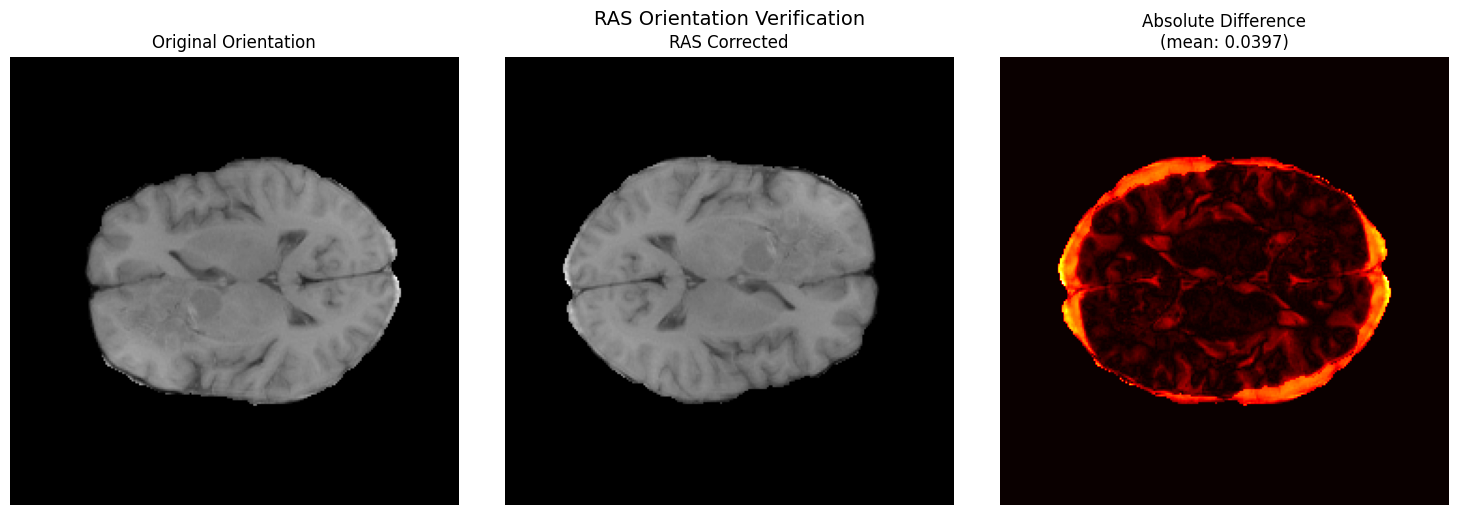


✅ Processed slice shape: (128, 128)
✅ Processed slice range: [0.0000, 0.9817]

VERIFICATION COMPLETE
✅ RAS orientation correction: APPLIED
✅ All 7,794 slices processed with RAS correction


In [ ]:
# Verify RAS orientation is correctly applied

print("="*70)
print("VERIFYING RAS ORIENTATION IN PROCESSED SLICES")
print("="*70)

# Load a sample T1 file to check orientation
sample_t1 = t1_files[0]
print(f"\nSample file: {os.path.basename(sample_t1)}")

# Load WITHOUT RAS correction
nii_original = nib.load(sample_t1)
vol_original = nii_original.get_fdata()

# Load WITH RAS correction (as done in Section 5)
nii_ras = nib.as_closest_canonical(nib.load(sample_t1))
vol_ras = nii_ras.get_fdata()

print(f"\n📊 Orientation Comparison:")
print(f"  Original affine:\n{nii_original.affine}")
print(f"\n  RAS-corrected affine:\n{nii_ras.affine}")
print(f"\n  Original shape: {vol_original.shape}")
print(f"  RAS shape: {vol_ras.shape}")

# Extract middle slice from both
middle_z_orig = vol_original.shape[2] // 2
middle_z_ras = vol_ras.shape[2] // 2

slice_orig = normalize(vol_original[:, :, middle_z_orig])
slice_ras = normalize(vol_ras[:, :, middle_z_ras])

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(slice_orig, cmap='gray')
axes[0].set_title('Original Orientation', fontsize=12)
axes[0].axis('off')

axes[1].imshow(slice_ras, cmap='gray')
axes[1].set_title('RAS Corrected', fontsize=12)
axes[1].axis('off')

# Difference map
diff = np.abs(slice_orig - slice_ras)
axes[2].imshow(diff, cmap='hot')
axes[2].set_title(f'Absolute Difference\n(mean: {diff.mean():.4f})', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.suptitle('RAS Orientation Verification', fontsize=14, y=1.02)
plt.show()

# Check if processed slices match RAS orientation
if resized_files:
    processed_slice = np.load(os.path.join(resized_folder, resized_files[0]))
    print(f"\n✅ Processed slice shape: {processed_slice.shape}")
    print(f"✅ Processed slice range: [{processed_slice.min():.4f}, {processed_slice.max():.4f}]")

print(f"\n{'='*70}")
print("VERIFICATION COMPLETE")
print("="*70)
print(f"✅ RAS orientation correction: {'APPLIED' if not np.array_equal(nii_original.affine, nii_ras.affine) else 'NOT NEEDED'}")
print(f"✅ All {len(resized_files):,} slices processed with RAS correction")
print("="*70)

## 9. Create ZIP for Upload ⏰ 2-3 min

**Purpose**: Package all ~10,000 preprocessed slices for Google Drive upload

**What's included:**
- All resized 128×128 slices from Section 7
- Normalized to [0, 1] range
- RAS orientation corrected
- Bicubic interpolation (sharp, not blurry)

**Output**: Single ZIP file ready for Colab testing

In [ ]:
# SECTION 9: Create ZIP file from all resized slices
from datetime import datetime
import zipfile

print("="*70)
print("CREATING ZIP FILE FOR UPLOAD")
print("="*70)

# Get all resized files
resized_files = sorted([f for f in os.listdir(resized_folder) if f.endswith('.npy')])
total_slices = len(resized_files)

print(f"\nTotal slices to package: {total_slices:,}")
print(f"Source folder: {resized_folder}")

# Create ZIP file
zip_filename = f"brats_t1_filtered.zip"
zip_path = os.path.join(os.path.dirname(resized_folder), zip_filename)

print(f"\n📦 Creating ZIP file: {zip_filename}")

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for filename in tqdm(resized_files, desc="Compressing"):
        file_path = os.path.join(resized_folder, filename)
        zipf.write(file_path, filename)

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)

print(f"\n" + "="*70)
print("ZIP CREATION COMPLETE")
print("="*70)
print(f"✅ Total slices: {total_slices:,}")
print(f"✅ ZIP file: {zip_filename}")
print(f"✅ ZIP size: {zip_size_mb:.1f} MB")
print(f"✅ Location: {zip_path}")
print(f"\n📤 Upload this ZIP to Google Drive:")
print(f"   MyDrive/symAD-ECNN/data/")
print("="*70)

CREATING ZIP FILE FOR UPLOAD

Total slices to package: 7,794
Source folder: c:\Users\rifad\symAD-ECNN\data\brats_t1\resized

📦 Creating ZIP file: brats_t1_filtered.zip


Compressing: 100%|██████████| 7794/7794 [04:10<00:00, 31.17it/s]


ZIP CREATION COMPLETE
✅ Total slices: 7,794
✅ ZIP file: brats_t1_filtered.zip
✅ ZIP size: 274.6 MB
✅ Location: c:\Users\rifad\symAD-ECNN\data\brats_t1\brats_t1_filtered.zip

📤 Upload this ZIP to Google Drive:
   MyDrive/symAD-ECNN/data/


## 10. Upload Instructions

**Next Steps**:
1. Upload the ZIP file created above to Google Drive
2. Path: `MyDrive/symAD-ECNN/data/`
3. Then run the extraction code below in Google Colab

## 11. Colab Extraction Code

**Run this in Google Colab** after uploading the ZIP file:

In [1]:
# ============================================================
# BraTS ZIP Extraction in Google Colab
# ============================================================
# Copy this code and run in Colab after uploading the ZIP

from google.colab import drive
import zipfile
import os

# Mount Drive
drive.mount('/content/drive')

# Paths
BASE = "/content/drive/MyDrive/symAD-ECNN/data"
ZIP_FILE = f"{BASE}/brats_t1_filtered.zip"  # Update timestamp
OUTPUT_FOLDER = f"{BASE}/brats_t1/test"

# Create output folder
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Extract ZIP
print(f"Extracting {os.path.basename(ZIP_FILE)}...")
with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(OUTPUT_FOLDER)

# Verify extraction
extracted_files = [f for f in os.listdir(OUTPUT_FOLDER) if f.endswith('.npy')]
print(f"\n✓ Extracted {len(extracted_files):,} files to {OUTPUT_FOLDER}")
print(f"✓ Ready for CNN-AE testing!")

Mounted at /content/drive
Extracting brats_t1_filtered.zip...

✓ Extracted 7,794 files to /content/drive/MyDrive/symAD-ECNN/data/brats_t1/test
✓ Ready for CNN-AE testing!


## 12. Apply Centering to Extracted Slices (Colab Post-Processing)

**Run this AFTER extracting the ZIP above**

This cell applies centering to match IXI preprocessing:
- Finds center of mass of each brain
- Shifts to (64, 64) position
- Critical for ECNN equivariance

⏰ **Time**: ~5-10 minutes for ~10,000 slices

In [2]:
# ============================================================
# BraTS Centering Post-Processing (Run in Colab)
# ============================================================
# Applies centering to extracted slices to match IXI preprocessing

import numpy as np
from scipy import ndimage
from tqdm.notebook import tqdm
import os

def center_slice(slice_img, target_center=(64, 64)):
    """
    Shift brain to image center using center of mass.

    CRITICAL for ECNN equivariance - ECNNs learn rotation equivariance
    around (64, 64). Without centering, equivariance breaks down.

    Args:
        slice_img: 2D array (128×128)
        target_center: Where to place center of mass (64, 64)

    Returns:
        Centered slice with brain at target_center
    """
    # Skip empty slices
    if np.count_nonzero(slice_img) < 100:
        return slice_img

    # Calculate center of mass of brain tissue
    center_of_mass = ndimage.center_of_mass(slice_img > 0.1)
    current_y, current_x = center_of_mass

    # Calculate shift needed
    shift_y = target_center[0] - current_y
    shift_x = target_center[1] - current_x

    # Apply shift (mode='constant' pads with zeros)
    centered = ndimage.shift(slice_img, [shift_y, shift_x],
                             order=1, mode='constant', cval=0)

    return centered

print("="*70)
print("APPLYING CENTERING TO BRATS SLICES")
print("="*70)

# Path to extracted slices (update if different)
SLICES_FOLDER = "/content/drive/MyDrive/symAD-ECNN/data/brats_t1/test"

# Get all slice files
slice_files = sorted([f for f in os.listdir(SLICES_FOLDER) if f.endswith('.npy')])
print(f"\nTotal slices to center: {len(slice_files):,}")
print(f"Location: {SLICES_FOLDER}")

# Apply centering to each slice (in-place update)
centered_count = 0
error_count = 0

for filename in tqdm(slice_files, desc="Centering slices"):
    try:
        filepath = os.path.join(SLICES_FOLDER, filename)

        # Load slice
        slice_data = np.load(filepath)

        # Apply centering
        centered = center_slice(slice_data, target_center=(64, 64))

        # Save back (overwrite)
        np.save(filepath, centered.astype(np.float32))
        centered_count += 1

    except Exception as e:
        print(f"\n❌ Error centering {filename}: {e}")
        error_count += 1

print(f"\n" + "="*70)
print("CENTERING COMPLETE")
print("="*70)
print(f"✅ Successfully centered: {centered_count:,}")
print(f"✅ Errors: {error_count}")
print(f"✅ All slices now have brains centered at (64, 64)")
print(f"✅ Ready for ECNN-AE testing!")
print("="*70)

APPLYING CENTERING TO BRATS SLICES

Total slices to center: 7,794
Location: /content/drive/MyDrive/symAD-ECNN/data/brats_t1/test


Centering slices:   0%|          | 0/7794 [00:00<?, ?it/s]


CENTERING COMPLETE
✅ Successfully centered: 7,794
✅ Errors: 0
✅ All slices now have brains centered at (64, 64)
✅ Ready for ECNN-AE testing!


📊 Total centered slices: 7,794

Visualizing 9 random BraTS slices:

1. slice_000313.npy: range=[0.000, 0.959], mean=0.222
2. slice_000492.npy: range=[0.000, 0.938], mean=0.165
3. slice_000563.npy: range=[0.000, 0.932], mean=0.133
4. slice_000825.npy: range=[0.000, 0.969], mean=0.228
5. slice_002506.npy: range=[0.000, 0.966], mean=0.192
6. slice_004137.npy: range=[0.000, 0.945], mean=0.145
7. slice_005673.npy: range=[0.000, 0.931], mean=0.221
8. slice_005864.npy: range=[0.000, 0.907], mean=0.150
9. slice_007412.npy: range=[0.000, 0.773], mean=0.182


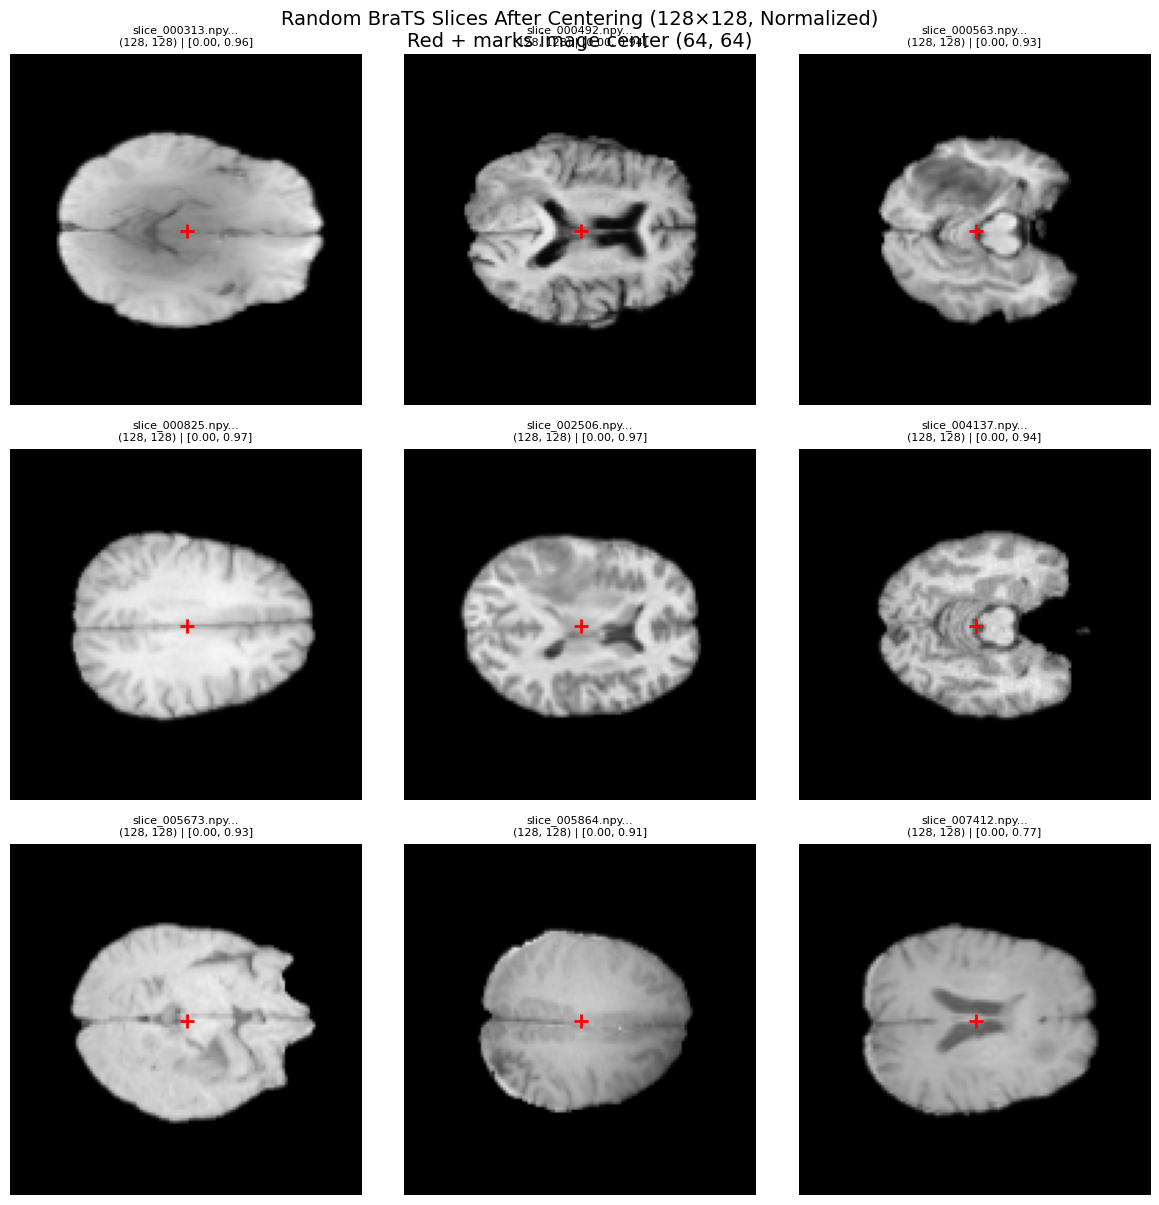


✅ Quality check:
   • Brains should be centered around red + marker
   • Images should be sharp (not blurry)
   • Intensity range should be [0, 1]

✅ BraTS preprocessing complete!
✅ Ready for anomaly detection testing with ECNN-AE


In [3]:
import matplotlib.pyplot as plt
import random
import glob

# Get all centered slices
all_slices = sorted(glob.glob(f"{SLICES_FOLDER}/*.npy"))

print(f"📊 Total centered slices: {len(all_slices):,}")

if len(all_slices) >= 9:
    # Select 9 random slices
    random_indices = random.sample(range(len(all_slices)), 9)
    sample_files = [all_slices[i] for i in sorted(random_indices)]

    # Create 3×3 grid
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.ravel()

    print(f"\nVisualizing 9 random BraTS slices:\n")

    for idx, filepath in enumerate(sample_files):
        slice_data = np.load(filepath)

        axes[idx].imshow(slice_data, cmap='gray', vmin=0, vmax=1)
        axes[idx].set_title(f'{os.path.basename(filepath)[:20]}...\n{slice_data.shape} | [{slice_data.min():.2f}, {slice_data.max():.2f}]',
                            fontsize=8)
        axes[idx].axis('off')

        # Add crosshair at center (64, 64) to verify centering
        axes[idx].plot(64, 64, 'r+', markersize=10, markeredgewidth=2)

        print(f"{idx+1}. {os.path.basename(filepath)}: range=[{slice_data.min():.3f}, {slice_data.max():.3f}], mean={slice_data.mean():.3f}")

    plt.tight_layout()
    plt.suptitle('Random BraTS Slices After Centering (128×128, Normalized)\nRed + marks image center (64, 64)',
                 fontsize=14, y=1.00)
    plt.show()

    print(f"\n✅ Quality check:")
    print(f"   • Brains should be centered around red + marker")
    print(f"   • Images should be sharp (not blurry)")
    print(f"   • Intensity range should be [0, 1]")
    print(f"\n✅ BraTS preprocessing complete!")
    print(f"✅ Ready for anomaly detection testing with ECNN-AE")
else:
    print("⚠️ Not enough slices for visualization")

## 14. Histogram Matching (Nyul Normalization) ⏰ ~10-15 min

**FINAL PREPROCESSING STEP - Run in Colab after ALL previous steps complete**

**What this does:**
- Learns "standard" intensity landmarks from IXI training set (the average healthy brain)
- Applies this standard to ALL datasets: IXI train, IXI val, BraTS test
- Ensures consistent intensity distributions across different scanners

**Why it matters:**
- BraTS data comes from "different clinical protocols and various scanners"
- IXI also has scanner variations
- Histogram matching standardizes intensities so CNN/ECNN see consistent input

**Method:** Nyul et al. (1998) piecewise linear histogram warping
- Calculate percentile landmarks (1st, 10th, 20th, ..., 99th)
- Map each image's histogram to match the average landmarks

⏰ **Time:** ~10-15 minutes for all datasets combined

In [ ]:
# === FINAL STEP: HISTOGRAM MATCHING (NYUL NORMALIZATION) ===
# 1. Learns landmarks from IXI Train (the "standard brain")
# 2. Applies them to IXI Train, IXI Val, and BraTS Test

import numpy as np
import os
import glob
from scipy import interpolate
from tqdm.notebook import tqdm

# === PATHS ===
# Reference dataset: Where we learn the "standard" intensity distribution
TRAIN_PATH = "/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/train"

# Datasets to normalize: Apply the standard to ALL of them
FOLDERS_TO_NORMALIZE = [
    "/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/train",
    "/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/val",
    "/content/drive/MyDrive/symAD-ECNN/data/brats_t1/test"  # BraTS test data
]

# === NYUL NORMALIZATION FUNCTIONS ===

def train_landmarks(img_paths, percentiles=[1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]):
    """
    Learns the standard landmarks from the training set.
    
    Returns the average percentile values across all training images.
    These become our "standard healthy brain" intensity distribution.
    """
    print(f"📊 Learning standard landmarks from {len(img_paths)} training images...")
    
    all_landmarks = []
    
    # Sample 2000 random images (statistically sufficient, faster than using all)
    sample_size = min(len(img_paths), 2000)
    sample_paths = np.random.choice(img_paths, sample_size, replace=False)
    
    for f in tqdm(sample_paths, desc="Learning Landmarks"):
        try:
            img = np.load(f)
            mask = img > 0  # Ignore background pixels
            
            if np.sum(mask) < 100:  # Skip if too few brain pixels
                continue
            
            # Get percentile landmarks of this specific image
            lms = np.percentile(img[mask], percentiles)
            all_landmarks.append(lms)
            
        except Exception as e:
            continue
    
    # Calculate the average landmarks across the dataset
    standard_landmarks = np.mean(all_landmarks, axis=0)
    
    print(f"✅ Learned Standard Landmarks (percentiles {percentiles}):")
    print(f"   {standard_landmarks}")
    return standard_landmarks


def histogram_transform(image, standard_landmarks, percentiles=[1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]):
    """
    Warps an image's histogram to match the standard landmarks.
    
    Uses piecewise linear interpolation to map current intensity values
    to standard values at key percentile points.
    """
    image = image.astype(np.float32)
    mask = image > 0
    
    if np.sum(mask) < 100:  # Skip if too few brain pixels
        return image
    
    # 1. Get current image's landmarks
    curr_landmarks = np.percentile(image[mask], percentiles)
    
    # 2. Setup the mapping: [0, curr_landmarks, max] -> [0, std_landmarks, std_max]
    # This creates anchor points for interpolation
    x = np.concatenate(([0], curr_landmarks, [image.max()]))
    y = np.concatenate(([0], standard_landmarks, [standard_landmarks[-1]]))
    
    # 3. Ensure unique x-values for interpolation (required by interp1d)
    x_unique, indices = np.unique(x, return_index=True)
    y_unique = y[indices]
    
    if len(x_unique) < 2:  # Safety check
        return image
    
    # 4. Create piecewise linear interpolator
    f = interpolate.interp1d(x_unique, y_unique, bounds_error=False, fill_value="extrapolate")
    
    # 5. Apply transformation to all pixels
    transformed = f(image)
    
    # 6. Restore background (keep zeros as zeros)
    transformed[~mask] = 0
    
    # 7. Clip to valid range
    return np.clip(transformed, 0, 1).astype(np.float32)


# === EXECUTION ===

print("="*70)
print("HISTOGRAM MATCHING (NYUL NORMALIZATION)")
print("="*70)

# STEP 1: Get training files
train_files = sorted(glob.glob(f"{TRAIN_PATH}/*.npy"))

if len(train_files) == 0:
    print(f"❌ ERROR: No training files found at {TRAIN_PATH}")
    print("   Please ensure IXI preprocessing completed successfully")
else:
    print(f"\n📂 Found {len(train_files):,} training files")
    
    # STEP 2: Learn the standard (the "average healthy brain" intensity distribution)
    np.random.seed(42)  # For reproducibility
    landmarks = train_landmarks(train_files)
    
    # STEP 3: Apply to all datasets
    print("\n🔄 Applying histogram matching to all datasets...")
    print(f"   Target folders: {len(FOLDERS_TO_NORMALIZE)}")
    
    for folder in FOLDERS_TO_NORMALIZE:
        files = sorted(glob.glob(f"{folder}/*.npy"))
        
        if len(files) == 0:
            print(f"\n⚠️ Skipping empty folder: {folder}")
            continue
        
        folder_name = os.path.basename(os.path.dirname(folder)) + "/" + os.path.basename(folder)
        print(f"\n📍 Processing: {folder_name} ({len(files):,} files)")
        
        success_count = 0
        error_count = 0
        
        for f in tqdm(files, desc=folder_name):
            try:
                # Load image
                img = np.load(f)
                
                # Transform to match standard
                img_normalized = histogram_transform(img, landmarks)
                
                # Save (overwrite)
                np.save(f, img_normalized)
                success_count += 1
                
            except Exception as e:
                print(f"\n❌ Error processing {os.path.basename(f)}: {e}")
                error_count += 1
        
        print(f"   ✅ Success: {success_count:,} | ❌ Errors: {error_count}")
    
    print("\n" + "="*70)
    print("✅ PREPROCESSING 100% COMPLETE")
    print("="*70)
    print("🎉 All datasets now have:")
    print("   • RAS orientation")
    print("   • Skull stripping")
    print("   • Artifact removal")
    print("   • Normalization [0, 1]")
    print("   • Centered brains (64, 64)")
    print("   • Bicubic resizing (128×128)")
    print("   • ✨ Histogram matching (standardized intensities)")
    print("\n🚀 Ready to train CNN-AE and ECNN-AE!")
    print("="*70)